In [1]:
# === [1] ROS + Interface Setup ===
import rospy
import actionlib
from assignment_2_2024.msg import PlanningAction, PlanningGoal
from nav_msgs.msg import Odometry
from sensor_msgs.msg import LaserScan
from Simulation_pkg.msg import PositionVelocity
import threading
import time
import ipywidgets as widgets
from IPython.display import display, clear_output

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


class Visualiser:
    def __init__(self):
        self.fig, self.ax = plt.subplots()
        self.ln, = self.ax.plot([], [], 'b-', label='Robot Path')
        self.x_data, self.y_data = [], []

    def plot_init(self):
        self.ax.set_xlim(-10, 10)
        self.ax.set_ylim(-10, 10)
        self.ax.set_title("Live Robot Trajectory")
        self.ax.set_xlabel("X")
        self.ax.set_ylabel("Y")
        self.ax.grid(True)
        self.ax.legend()
        return self.ln,

    def odom_callback(self, msg):
        self.x_data.append(msg.pose.pose.position.x)
        self.y_data.append(msg.pose.pose.position.y)

    def update_plot(self, frame):
        self.ln.set_data(self.x_data, self.y_data)
        return self.ln,
    
class GoalStatsVisualizer:
    def __init__(self):
        self.reached = 0
        self.aborted = 0
        self.fig, self.ax = plt.subplots()
        self.bars = self.ax.bar(['Reached', 'Aborted'], [0, 0], color=['green', 'red'])
        self.ax.set_ylim(0, 10)
        self.ax.set_ylabel("Count")
        self.ax.set_title("Goals Reached vs Aborted")

    def update(self, frame):
        self.bars[0].set_height(self.reached)
        self.bars[1].set_height(self.aborted)
        return self.bars

    def increment_reached(self):
        self.reached += 1

    def increment_aborted(self):
        self.aborted += 1


# ROS Node
rospy.init_node('jupyter_action_client', anonymous=True, disable_signals=True)

# Globals
position_velocity_pub = rospy.Publisher("position_velocity", PositionVelocity, queue_size=10)
pos_vel_msg = PositionVelocity()
ac = actionlib.SimpleActionClient('/reaching_goal', PlanningAction)
ac_lock = threading.Lock()
goal_reached = False
request_coordinates = False








In [2]:
# === [2] Interface Widgets ===
status_output = widgets.Output()
position_display = widgets.HTML("<b>Current Position:</b> Waiting for data...")
velocity_display = widgets.HTML("<b>Current Velocity:</b> Waiting for data...")
obstacle_distance_display = widgets.HTML("<b>Closest Obstacle:</b> Waiting for data...")
target_display = widgets.HTML("<b>Target Position:</b> None")

x_input = widgets.FloatText(value=0.0, description='X:')
y_input = widgets.FloatText(value=0.0, description='Y:')

set_goal_button = widgets.Button(description='Set Goal', button_style='success', icon='check')
cancel_button = widgets.Button(description='Cancel Goal', button_style='danger', icon='stop')

In [3]:
# === [3] ROS Callbacks ===
def odom_callback(msg):
    pos_vel_msg.x = msg.pose.pose.position.x
    pos_vel_msg.y = msg.pose.pose.position.y
    pos_vel_msg.vel_x = msg.twist.twist.linear.x
    pos_vel_msg.vel_z = msg.twist.twist.angular.z

    position_display.value = f"<b>Current Position:</b> X: {pos_vel_msg.x:.2f}, Y: {pos_vel_msg.y:.2f}"
    velocity_display.value = f"<b>Current Velocity:</b> Linear: {pos_vel_msg.vel_x:.2f}, Angular: {pos_vel_msg.vel_z:.2f}"
    position_velocity_pub.publish(pos_vel_msg)
    x_path.append(pos_vel_msg.x)
    y_path.append(pos_vel_msg.y)

def scan_callback(msg):
    valid_ranges = [r for r in msg.ranges if not rospy.is_shutdown() and not (r == float('inf') or r != r)]
    if valid_ranges:
        closest = min(valid_ranges)
        obstacle_distance_display.value = f"<b>Closest Obstacle:</b> {closest:.2f} meters"
    else:
        obstacle_distance_display.value = "<b>Closest Obstacle:</b> No valid data"



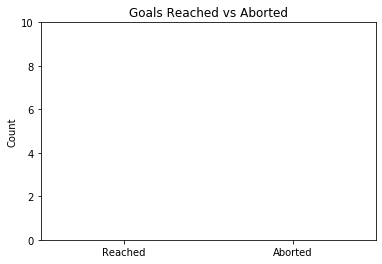

In [4]:
# === [4] Goal Monitor Thread ===
reached_count = 0
aborted_count = 0
x_path = []
y_path = []

stats_vis = GoalStatsVisualizer()


def monitor_goal_status():
    global goal_reached, request_coordinates
    rate = rospy.Rate(10)
    while not rospy.is_shutdown():
        with ac_lock:
            if ac:
                state = ac.get_state()
                if state == actionlib.GoalStatus.SUCCEEDED and not goal_reached:
                    stats_vis.increment_reached()  # ✅ usa la classe
                    with status_output:
                        clear_output(wait=True)
                        print("Target reached!")
                    goal_reached = True
                    request_coordinates = False
                elif state == actionlib.GoalStatus.ABORTED:
                    stats_vis.increment_aborted()  # ✅ usa la classe
                    with status_output:
                        clear_output(wait=True)
                        print("Target could not be reached. Please set a new goal.")
                    goal_reached = True
                    request_coordinates = False
        rate.sleep()


In [5]:


# === [5] Goal Control Buttons ===
def on_set_goal_button_clicked(b):
    global goal_reached
    x = x_input.value
    y = y_input.value

    if not (isinstance(x, float) and isinstance(y, float) and x == x and y == y):
        with status_output:
            clear_output(wait=True)
            print("Invalid input. Both x and y must be finite numbers.")
        return

    pos_vel_msg.target_x = x
    pos_vel_msg.target_y = y
    goal = PlanningGoal()
    goal.target_pose.header.frame_id = "map"
    goal.target_pose.header.stamp = rospy.Time.now()
    goal.target_pose.pose.position.x = x
    goal.target_pose.pose.position.y = y
    goal.target_pose.pose.orientation.w = 1.0

    with ac_lock:
        ac.send_goal(goal)

    target_display.value = f"<b>Target Position:</b> X: {x:.2f}, Y: {y:.2f}"
    goal_reached = False
    with status_output:
        clear_output(wait=True)
        print(f"Goal sent to ({x:.2f}, {y:.2f}).")

def on_cancel_button_clicked(b):
    global request_coordinates
    with ac_lock:
        ac.cancel_goal()
    with status_output:
        clear_output(wait=True)
        print("Goal canceled.")
    request_coordinates = False

set_goal_button.on_click(on_set_goal_button_clicked)
cancel_button.on_click(on_cancel_button_clicked)

Waiting for Action server...
Action server available.


[ERROR] [1744473086.058989, 2415.131000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473086.101270, 2415.173000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473086.145857, 2415.221000]: bad callback: <bound method Visualiser.odom_callback of <__main_

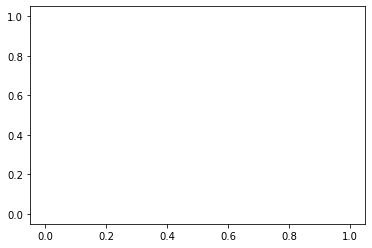

In [6]:
# === [6] Display UI ===
input_widgets = widgets.HBox([x_input, y_input])
button_widgets = widgets.HBox([set_goal_button, cancel_button])
info_widgets = widgets.VBox([
    position_display,
    velocity_display,
    obstacle_distance_display,
    target_display
])
ui = widgets.VBox([info_widgets, input_widgets, button_widgets, status_output])

try:
    print("Waiting for Action server...")
    ac.wait_for_server()
    print("Action server available.")

    monitor_thread = threading.Thread(target=monitor_goal_status)
    monitor_thread.daemon = True
    monitor_thread.start()

    #odom_sub = rospy.Subscriber("/odom", Odometry, odom_callback)
    # === [6.1] Create visualiser and subscribe to odom ===
    vis = Visualiser()
    odom_sub = rospy.Subscriber("/odom", Odometry, vis.odom_callback)

    
    scan_sub = rospy.Subscriber("/scan", LaserScan, scan_callback)

    display(ui)

except rospy.ROSInterruptException:
    print("ROS node interrupted")
except Exception as e:
    print(f"Error: {str(e)}")




[ERROR] [1744473086.307781, 2415.367000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473086.353484, 2415.407000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473086.424489, 2415.467000]: bad callback: <bound method Visualiser.odom_callback of <__main_

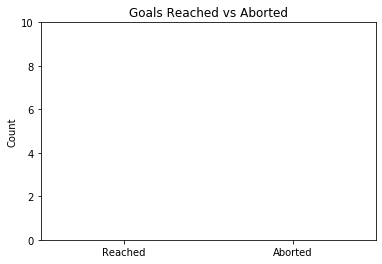

[ERROR] [1744473086.526721, 2415.539000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'



In [7]:
# === [7] Visualization Section ===
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

'''
fig1, ax1 = plt.subplots()
line1, = ax1.plot([], [], 'b-', label='Path')
ax1.set_title("Robot Path")
ax1.set_xlim(-10, 10)
ax1.set_ylim(-10, 10)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.grid(True)
ax1.legend()

def init_path():
    line1.set_data([], [])
    return line1,

def update_path(frame):
    line1.set_data(x_path, y_path)
    return line1,

ani1 = FuncAnimation(fig1, update_path, init_func=init_path, blit=True)
display(fig1)
'''


'''
# === [7.1] Start the path animation ===
ani_path = FuncAnimation(vis.fig, vis.update_plot, init_func=vis.plot_init, blit=True, interval=100)
display(vis.fig)


fig2, ax2 = plt.subplots()
bars = ax2.bar(['Reached', 'Aborted'], [reached_count, aborted_count], color=['green', 'red'])
ax2.set_title("Goal Result Counts")
ax2.set_ylim(0, 10)
ax2.set_ylabel("Count")

def update_bar(frame):
    bars[0].set_height(reached_count)
    bars[1].set_height(aborted_count)
    return bars

ani2 = FuncAnimation(fig2, update_bar, interval=1000)
display(fig2)
'''

ani2 = FuncAnimation(stats_vis.fig, stats_vis.update, interval=1000)
display(stats_vis.fig)



In [8]:
# === [8] Cleanup ===
def cleanup():
    try:
        rospy.signal_shutdown("Notebook closing")
        print("ROS node shutdown")
    except:
        pass

import atexit
atexit.register(cleanup)

<function __main__.cleanup()>

[ERROR] [1744473086.577791, 2415.624000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473086.626976, 2415.669000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473086.671927, 2415.718000]: bad callback: <bound method Visualiser.odom_callback of <__main_

[ERROR] [1744473087.528808, 2416.569000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473087.580844, 2416.619000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473087.630429, 2416.669000]: bad callback: <bound method Visualiser.odom_callback of <__main_

[ERROR] [1744473088.591068, 2417.619000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473088.644962, 2417.670000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473088.691987, 2417.719000]: bad callback: <bound method Visualiser.odom_callback of <__main_

[ERROR] [1744473089.550568, 2418.569000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473089.609798, 2418.619000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473089.659712, 2418.668000]: bad callback: <bound method Visualiser.odom_callback of <__main_

...

[ERROR] [1744473107.633557, 2434.069000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473107.686104, 2434.119000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473107.731975, 2434.169000]: bad callback: <bound method Visualiser.odom_callback of <__main_

[ERROR] [1744473108.715427, 2435.119000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473108.787326, 2435.169000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473108.834718, 2435.219000]: bad callback: <bound method Visualiser.odom_callback of <__main_

[ERROR] [1744473109.845870, 2436.219000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473109.900006, 2436.270000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473109.959872, 2436.319000]: bad callback: <bound method Visualiser.odom_callback of <__main_

[ERROR] [1744473110.942076, 2437.269000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473110.992342, 2437.319000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473111.039771, 2437.366000]: bad callback: <bound method Visualiser.odom_callback of <__main_

[ERROR] [1744473111.902897, 2438.219000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473111.951380, 2438.269000]: bad callback: <bound method Visualiser.odom_callback of <__main__.Visualiser object at 0x7fecf820c040>>
Traceback (most recent call last):
  File "/opt/ros/noetic/lib/python3/dist-packages/rospy/topics.py", line 750, in _invoke_callback
    cb(msg)
  File "/tmp/ipykernel_3305/3324933921.py", line 29, in odom_callback
    self.y_data.append(msg.y)
AttributeError: 'Odometry' object has no attribute 'y'

[ERROR] [1744473112.002213, 2438.321000]: bad callback: <bound method Visualiser.odom_callback of <__main_